<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os



In [2]:
df = pd.read_csv("bslessma_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,intelowlproject_intelowl,000e0e7dea030138b58c620f37e307c5353c02ea,mlodic <30625432+mlodic@users.noreply.github.com>,1668081200,Update api_app/analyzers_manager/observable_an...,2022-11
1,intelowlproject_intelowl,00138170a167ee5f7ad5bc285e58917c4cc79616,Eshaan Bansal <eshaan7bansal@gmail.com>,1625520020,"small adjust, fixup\n",2021-07
2,intelowlproject_intelowl,001a97406771d99af0c107a653a897b167d995bb,Ramnath Kumar <ramnathkumar181@gmail.com>,1603026683,Added phishtank\n\nAdded to docs\n\nUpdated do...,2020-10
3,intelowlproject_intelowl,0020f7b19454fd82911fb5d24c6c78ffa0336b5d,dependabot[bot] <49699333+dependabot[bot]@user...,1718696254,Bump greynoise from 2.1.0 to 2.2.0 in /require...,2024-06
4,intelowlproject_intelowl,0025e1a26e67187c26b94a49539664488c54a4ff,0ssigeno <s.berni@certego.net>,1708072641,Fix default\n\nSigned-off-by: 0ssigeno <s.bern...,2024-02


In [3]:
projects = [
            'intelowlproject/IntelOwl',
            'intellistream/AllianceDB',
            'yesint/pteros',
            'cvnlab/analyzePRF',
            'simonfuhrmann/mve',
            'great-expectations/great_expectations',
            'google/grr',
            'projectcypress/cypress',
            'HyperHDG/HyperHDG',
            'MIT-SPARK/TEASER-plusplus'
            ]

df = pd.read_csv("bslessma_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')


for prj in projects:
  prj = prj.lower().replace('/','_',2)
  df1 = df[df['project']==prj]
  df2 = df1.groupby('Month').size().reset_index(name='Commits')
  
  monthly_counts = df2
  monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
  
  full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
  
  monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
  monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
  monthly_counts = monthly_counts.drop(columns='time')
  
  file_name = f"timeseries/bslessma_timeseries_{prj}.csv"
  monthly_counts.to_csv(file_name, index=False)
  print(f"Saved timeseries data for {prj} to {file_name}")
  

  

Saved timeseries data for intelowlproject_intelowl to timeseries/bslessma_timeseries_intelowlproject_intelowl.csv
Saved timeseries data for intellistream_alliancedb to timeseries/bslessma_timeseries_intellistream_alliancedb.csv
Saved timeseries data for yesint_pteros to timeseries/bslessma_timeseries_yesint_pteros.csv
Saved timeseries data for cvnlab_analyzeprf to timeseries/bslessma_timeseries_cvnlab_analyzeprf.csv
Saved timeseries data for simonfuhrmann_mve to timeseries/bslessma_timeseries_simonfuhrmann_mve.csv
Saved timeseries data for great-expectations_great_expectations to timeseries/bslessma_timeseries_great-expectations_great_expectations.csv
Saved timeseries data for google_grr to timeseries/bslessma_timeseries_google_grr.csv
Saved timeseries data for projectcypress_cypress to timeseries/bslessma_timeseries_projectcypress_cypress.csv
Saved timeseries data for hyperhdg_hyperhdg to timeseries/bslessma_timeseries_hyperhdg_hyperhdg.csv
Saved timeseries data for mit-spark_teaser-p

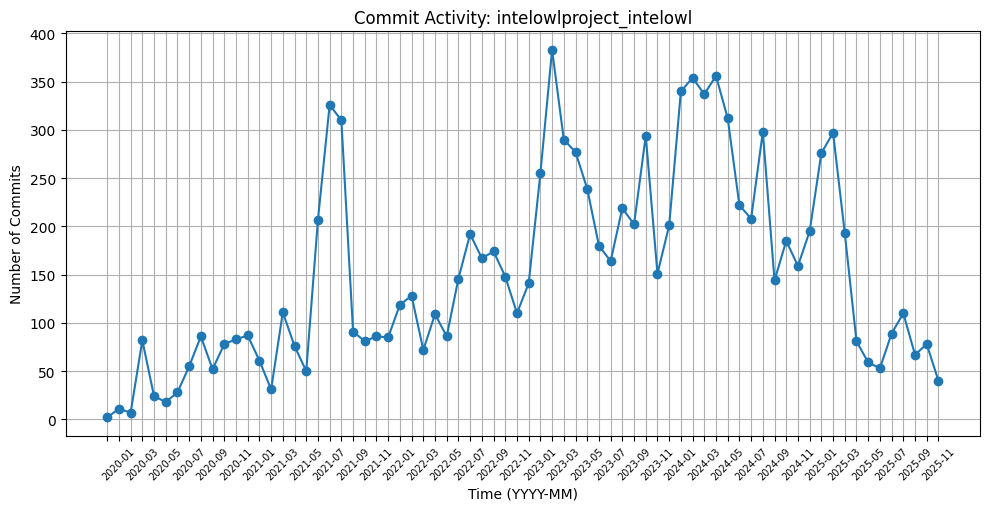

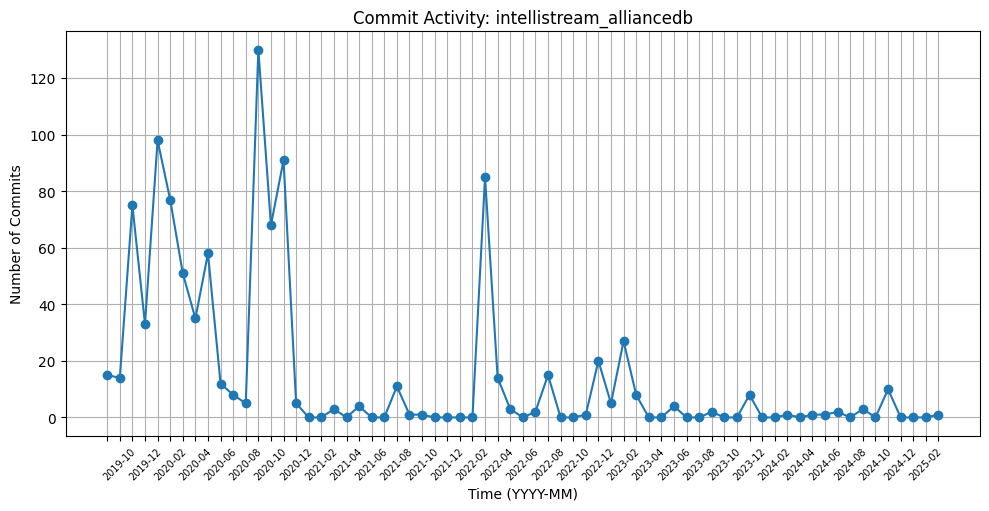

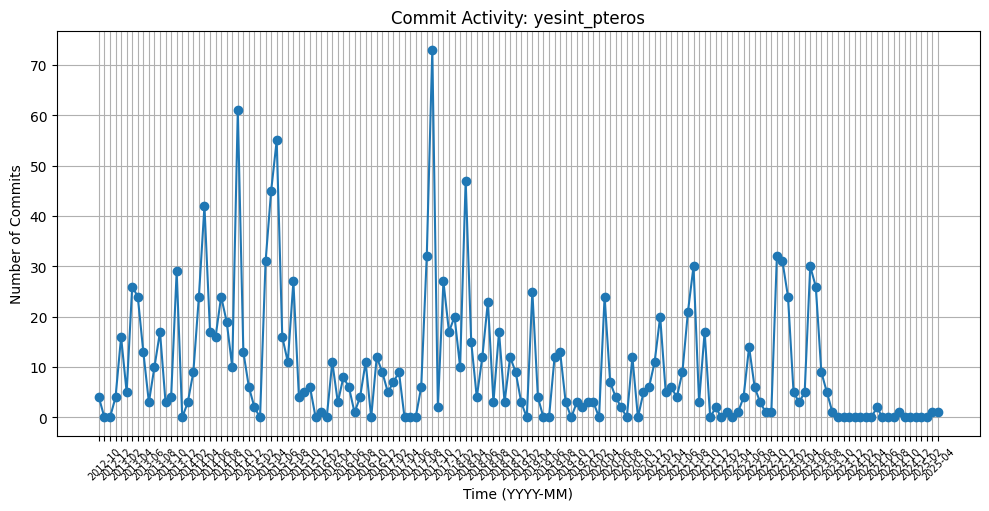

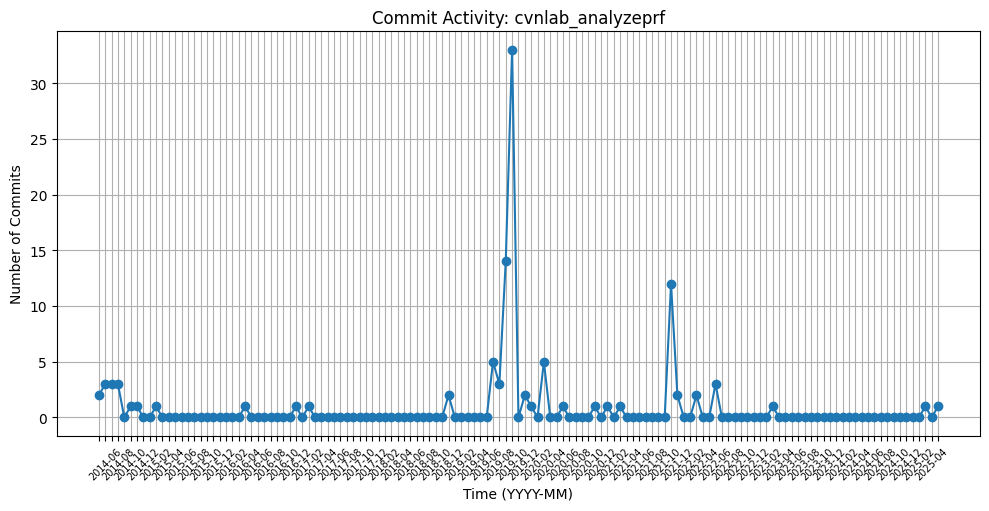

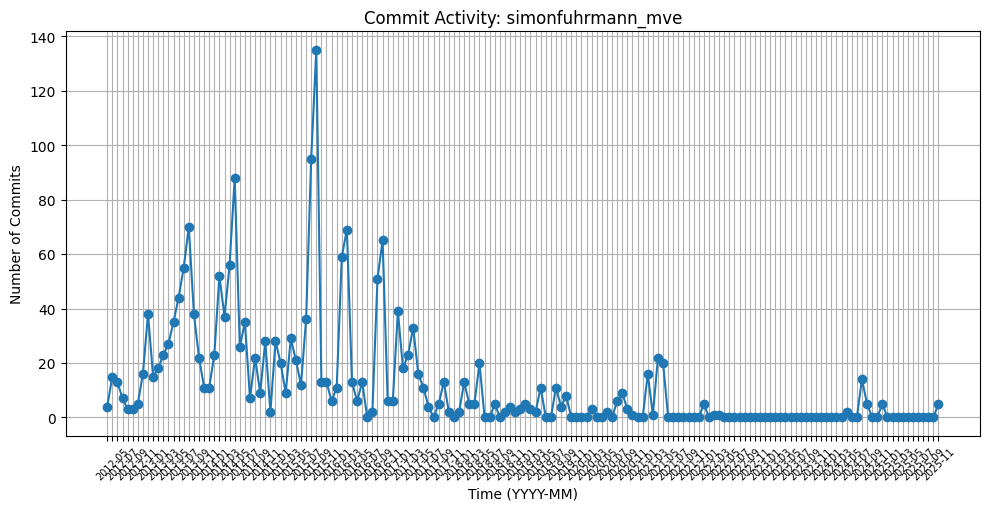

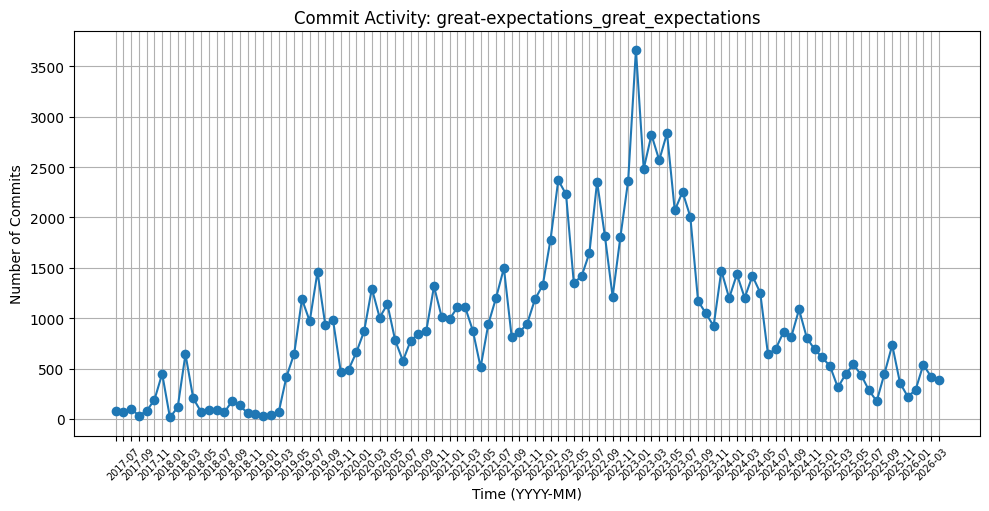

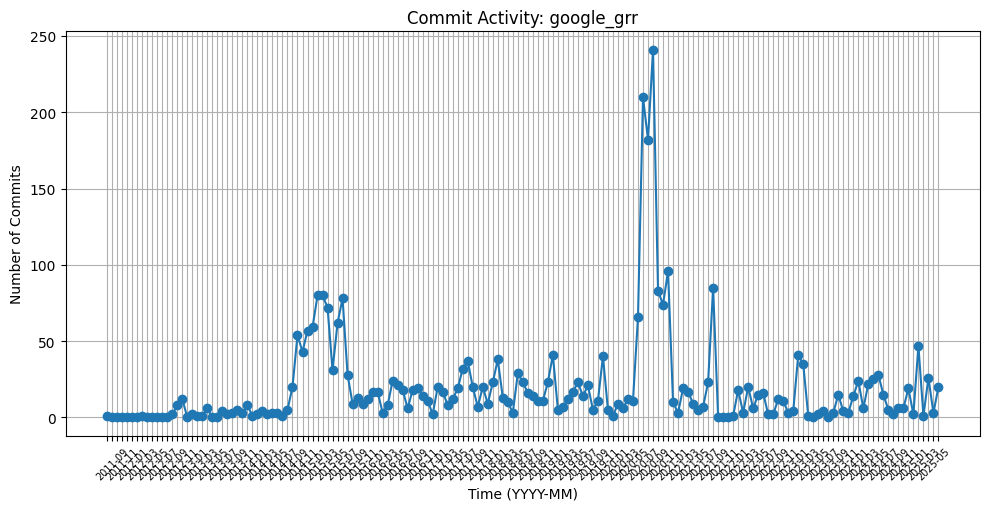

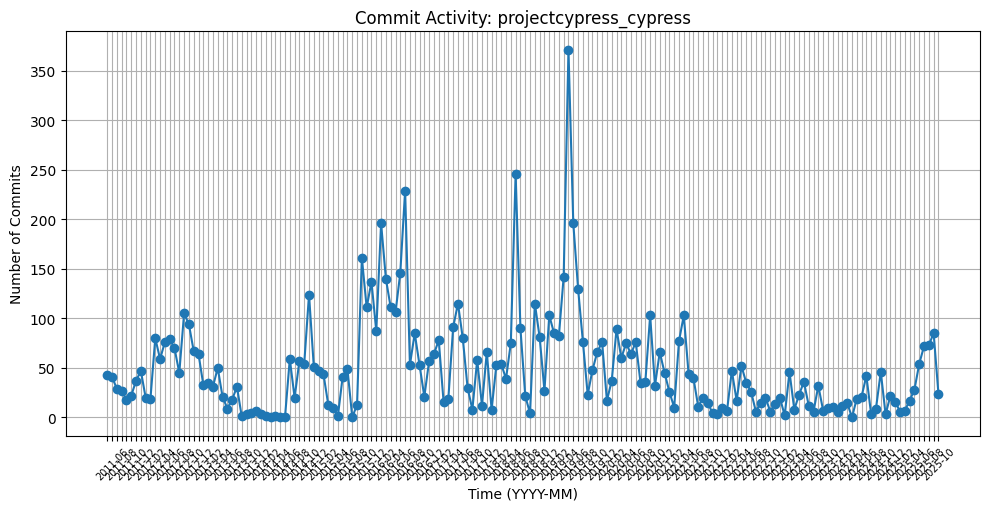

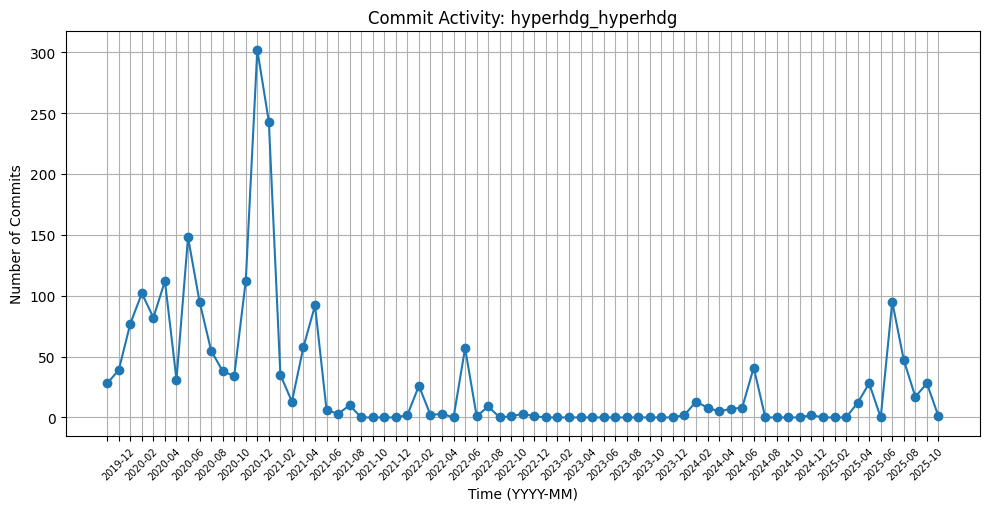

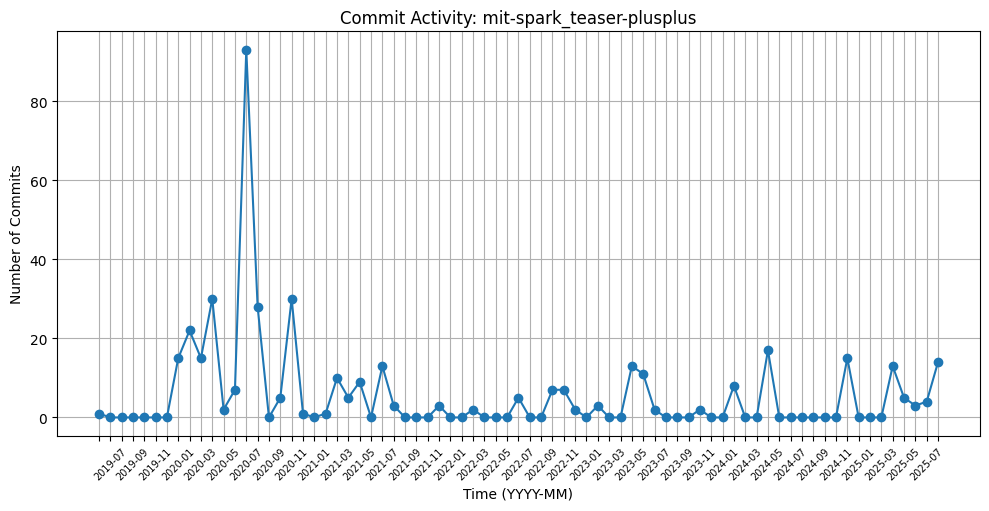

In [4]:
# Plot
import matplotlib.ticker as ticker

files = glob.glob("timeseries/*.csv")

for file in files:
    monthly_counts = pd.read_csv(file)
    prj = os.path.basename(file).replace("bslessma_timeseries_","").replace(".csv","")
    
    plt.figure(figsize=(10,5))
    plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title("Commit Activity: "+prj)
    plt.grid(True)
    plt.tight_layout()
    ax =  plt.gca()
    for label in ax.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)
    plt.xticks(rotation=45, fontsize=7)
    plt.savefig("timeseries_graphs/bslessma_timeseries_"+prj+".png", dpi=600)
    plt.show()
    plt.close()

# Identify the Longest Inactivity Gap

Add all that info to netid_project_stats.csv

In [5]:
files = glob.glob("timeseries/*.csv")

stats = pd.read_csv("bslessma_project_stats.csv")

for file in files:
    monthly_counts = pd.read_csv(file)

    prj = os.path.basename(file).replace(
        "bslessma_timeseries_", ""
    ).replace(".csv", "")

    longest_gap = 0
    longest_start = None
    longest_end = None
    num_gaps = 0

    current_gap = 0
    current_start = None

    for i, row in monthly_counts.iterrows():
        month = row['Month']
        commits = row['Commits']

        if commits == 0:
            if current_gap == 0:
                current_start = month
            current_gap += 1

        else:
            if current_gap >= 3:
                num_gaps += 1
            if current_gap > longest_gap:
                longest_gap = current_gap
                longest_start = current_start
                longest_end = monthly_counts.loc[i - 1, 'Month']

            current_gap = 0
            current_start = None

    # Handle a gap that extends all the way to the final month
    if current_gap >= 3:
        num_gaps += 1

        if current_gap > longest_gap:
            longest_gap = current_gap
            longest_start = current_start
            longest_end = monthly_counts.iloc[-1]['Month']

    if longest_end is not None:
        after_gap = monthly_counts[
            monthly_counts['Month'] > longest_end
        ]

        commits_after_gap = after_gap['Commits'].sum()
    else:
        commits_after_gap = 0

    project_row = stats['project'] == prj

    stats.loc[project_row, 'LongestGapStart'] = longest_start
    stats.loc[project_row, 'LongestGapEnd'] = longest_end
    stats.loc[project_row, 'LongestGapLength'] = longest_gap
    stats.loc[project_row, 'NumCommitsAfterLastGap'] = commits_after_gap
    stats.loc[project_row, 'NumberOfGapsInTimeline'] = num_gaps

stats.to_csv("bslessma_project_stats.csv", index=False)